REALWEAR INDUSTRIAL OPERATIONS ANALYTICS
         
WELCOME TO STATISTICAL ANALYSIS

In [1]:
# Import the Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import(shapiro,levene,f_oneway,ttest_ind,pearsonr,
                        spearmanr,chi2_contingency)
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("All Libraries imported successfully!")

All Libraries imported successfully!


In [2]:
#Load data From Sqlite

conn=sqlite3.connect(r'C:\Users\BIT\OneDrive\Desktop\REAL WEAR PROJECT\sql\database\realwear.db')

#Load main table
df=pd.read_sql_query("Select * from master_session_log",conn)
df_workers=pd.read_sql_query("Select * from Worker_Master",conn)
df_devices=pd.read_sql_query("Select * from device_health_log",conn)

conn.close()


In [3]:
print(f"Master Session Log:{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Session_ID             12000 non-null  object 
 1   Session_Date           12000 non-null  object 
 2   Shift                  12000 non-null  object 
 3   Plant_Location         12000 non-null  object 
 4   Plant_Zone             12000 non-null  object 
 5   Department             12000 non-null  object 
 6   Worker_ID              12000 non-null  object 
 7   Worker_Role            12000 non-null  object 
 8   Device_ID              12000 non-null  object 
 9   Platform               12000 non-null  object 
 10  Issue_Type             12000 non-null  object 
 11  Issue_Priority         12000 non-null  object 
 12  Meeting_Duration_min   12000 non-null  float64
 13  Resolution_Time_min    12000 non-null  float64
 14  Command_Attempts       12000 non-null  int64  
 15  Co

In [4]:
# Descriptive Statistics
#numeric columns

numeric_cols=[]
categorical_cols=[]
date_cols=[]
for i in df.columns:
    if df[i].dtype!='object':
        numeric_cols.append(i)
    elif df[i].dtype=='datetime64[ns]':
        date_cols.append(i)
    else:
        categorical_cols.append(i)

print(f"NUMERIC COLUMNS ({len(numeric_cols)}):")
print(f"CATEGORICAL COLUMNS ({len(categorical_cols)}):")
print(f"DateTime COLUMNS ({len(date_cols)}):")




NUMERIC COLUMNS (12):
CATEGORICAL COLUMNS (18):
DateTime COLUMNS (0):


In [5]:
# Complete Descriptive statsicts

desc_stats=df[numeric_cols].describe().T  #Transpose
desc_stats['skewness']=df[numeric_cols].skew()
desc_stats['median']=df[numeric_cols].median()
desc_stats['variance']=df[numeric_cols].var()   #population variance
desc_stats['cv%']=(df[numeric_cols].std()/df[numeric_cols].mean()*100).round(2)

print("=" * 60)
print("DESCRIPTIVE STATISTICS SUMMARY")
print("=" * 60)
print(desc_stats.round(2))

DESCRIPTIVE STATISTICS SUMMARY
                         count   mean    std   min    25%    50%   75%    max  \
Meeting_Duration_min   12000.0  29.89  14.59   5.0  17.27  29.70  42.7   55.0   
Resolution_Time_min    12000.0  49.26  29.05   4.4  25.80  44.40  68.3  137.1   
Command_Attempts       12000.0  27.28  10.44  10.0  18.00  27.00  37.0   45.0   
Command_Failures       12000.0   5.60   4.58   0.0   2.00   4.00   8.0   24.0   
Command_Success_Rate   12000.0  79.91  13.63  40.0  68.40  83.30  90.7  100.0   
Noise_Level_dB         12000.0  81.39  20.99  45.0  63.30  81.50  99.4  118.0   
Signal_Strength_dBm    12000.0 -61.47  13.89 -85.0 -74.00 -62.00 -49.0  -38.0   
Battery_Start_%        12000.0  70.11  17.61  40.0  55.00  70.00  86.0  100.0   
Battery_End_%          12000.0  58.08  18.45  19.0  43.00  58.00  73.0   97.0   
battery_drain_percent  12000.0  12.47   5.51   3.0   7.70  12.45  17.2   22.0   
Downtime_Saved_min     12000.0  49.75  26.08   5.0  27.10  49.70  72.0   95.0 

Why We Need to check whether Datas are normal or not 
Reason-- Before Doing test we need to whether the data is applying or not because there are two types of test
Parametric and non-parametric.

Parametric tests are those test where we have information about population (like mean,variance)
For this data should be normal

Non-Parametric test are those where we dont need any information about population


In [6]:
# NORAMALITY TEST (SHAPIRO-WILK)

from scipy.stats import shapiro

print("="*40)
print("Normality Test Results")
print("="*40)
print(f"HO: Data is normally distributes")
print(f"H1: Data is not normally distributes")
print(f"Significance Level:0.05")

normality_results={}

for i in numeric_cols:
    ##Shapiro_Wilk works best with sample<5000
    # With 12,000 rows it becomes too sensitive — detects tiny deviations as non-normal
    sample=df[i].dropna().sample(5000,random_state=42)
    stat,p_value=shapiro(sample)

    normality_results[i]={'statistics':round(stat,4),
                          'pvalue':round(p_value,4),
                           'normal': 'Yes'if p_value>0.05 else 'No'}
    
    print(f"{i:30} | stat={stat:.4f} | p={p_value:.4f} | Normal: {'Yes' if p_value > 0.05 else 'No'}")


Normality Test Results
HO: Data is normally distributes
H1: Data is not normally distributes
Significance Level:0.05
Meeting_Duration_min           | stat=0.9540 | p=0.0000 | Normal: No
Resolution_Time_min            | stat=0.9526 | p=0.0000 | Normal: No
Command_Attempts               | stat=0.9502 | p=0.0000 | Normal: No
Command_Failures               | stat=0.8907 | p=0.0000 | Normal: No
Command_Success_Rate           | stat=0.9436 | p=0.0000 | Normal: No
Noise_Level_dB                 | stat=0.9567 | p=0.0000 | Normal: No
Signal_Strength_dBm            | stat=0.9524 | p=0.0000 | Normal: No
Battery_Start_%                | stat=0.9564 | p=0.0000 | Normal: No
Battery_End_%                  | stat=0.9762 | p=0.0000 | Normal: No
battery_drain_percent          | stat=0.9553 | p=0.0000 | Normal: No
Downtime_Saved_min             | stat=0.9544 | p=0.0000 | Normal: No
Productivity_Score             | stat=0.8463 | p=0.0000 | Normal: No


The Above result shows that data is not normally distributed so we have two option we can do
1. Tranforming the data using Log-transformation to normalise skewed data

2. We can Use non-parametric test like Mann_whitney Utest 
kruskal-Wallis test

Lets Explore Both the ways

In [7]:
# 1. Log Transformation

#Apply log transformation
#np.log1p will be used insted of np,log
# Reason would be 
# np.log(0)  = undefined (-infinity) 
#np.log1p(0) = log(1+0) = 0 
skewed_cols=numeric_cols.copy()
for col in skewed_cols:
    df[f'log_{col}']=np.log1p(df[col])
print(" log transformed")

for col in skewed_cols:
    print(f"log_{col}")

#Retest Normality on transformed Columns
log_cols=[f'log_{col}' for col in skewed_cols]

print("Normaality Test After Log transformation")

for col in log_cols:
     # Check if column exists and has enough values
    if col not in df.columns:
        print(f"{col:35} | Column not found")
        continue
    
    valid_data = df[col].dropna()
    
    if len(valid_data) == 0:
        print(f"{col:35} | No valid data")
        continue
    sample=df[col].dropna().sample(5000,random_state=42)
    stat,p_value=shapiro(sample)
    print(f"{col:35} | p={p_value:.4f} | Normal: {'Yes' if p_value > 0.05 else 'No'}")




 log transformed
log_Meeting_Duration_min
log_Resolution_Time_min
log_Command_Attempts
log_Command_Failures
log_Command_Success_Rate
log_Noise_Level_dB
log_Signal_Strength_dBm
log_Battery_Start_%
log_Battery_End_%
log_battery_drain_percent
log_Downtime_Saved_min
log_Productivity_Score
Normaality Test After Log transformation
log_Meeting_Duration_min            | p=0.0000 | Normal: No
log_Resolution_Time_min             | p=0.0000 | Normal: No
log_Command_Attempts                | p=0.0000 | Normal: No
log_Command_Failures                | p=0.0000 | Normal: No
log_Command_Success_Rate            | p=0.0000 | Normal: No
log_Noise_Level_dB                  | p=0.0000 | Normal: No
log_Signal_Strength_dBm             | No valid data
log_Battery_Start_%                 | p=0.0000 | Normal: No
log_Battery_End_%                   | p=0.0000 | Normal: No
log_battery_drain_percent           | p=0.0000 | Normal: No
log_Downtime_Saved_min              | p=0.0000 | Normal: No
log_Productivity_Scor


CONCLUSION:
- All numeric columns failed normality test before transformation
- Log transformation applied to skewed columns
- All columns still failed normality test after transformation
- Reason: Real world industrial data rarely follows perfect 
  normal distribution with 12,000 rows
- Decision: Use NON-PARAMETRIC tests for all hypothesis testing
  
  T-Test → Mann-Whitney U Test
  ANOVA  → Kruskal-Wallis Test
  
- Effect Size will be calculated alongside p-values to measure
  PRACTICAL significance not just statistical significance
  
  Data was not perfectly normal however given our large sample size of 12,000 rows Central Limit Theorem applies. I ran both parametric tests (ANOVA, T-Test) and non-parametric alternatives (Kruskal-Wallis, Mann-Whitney) and compared results for robustness.


In [8]:
# CENTRAL LIMIT THEOREM VERIFICATION
df['Noise_Level_dB'] = pd.to_numeric(df['Noise_Level_dB'], errors='coerce')
print(f'Total sample size:{len(df)}')
print()

groups={
    'Platform groups':df.groupby('Platform').size(),
    'Shift groups':df.groupby('Shift').size(),
    'Plant groups':df.groupby('Plant_Location').size(),
    'Noise_category Groups': df.groupby(pd.cut(df['Noise_Level_dB'],bins=[0,70,85,100],labels=['Low','medium','High'])).size(),
    'External Mic Groups':df.groupby('External_Mic_Used').size()


}
for group_name ,size in groups.items():
    print(f"{group_name}")
    for name ,size in size.items():
        clt_status="CLT APPLIES" if size>30 else "CLT CANNOT APPLY"
        print(f"{name}:{size} {clt_status}")

Total sample size:12000

Platform groups
MS Teams:8189 CLT APPLIES
Webex:3811 CLT APPLIES
Shift groups
Afternoon (14:00-22:00):4031 CLT APPLIES
Morning (06:00-14:00):3964 CLT APPLIES
Night (22:00-06:00):4005 CLT APPLIES
Plant groups
Bokaro Manufacturing Hub:2433 CLT APPLIES
Chennai Refinery Unit:2432 CLT APPLIES
Jamshedpur Steel Plant:2403 CLT APPLIES
Pune Automation Plant:2421 CLT APPLIES
Vadodara Chemical Unit:2311 CLT APPLIES
Noise_category Groups
Low:4150 CLT APPLIES
medium:2423 CLT APPLIES
High:2527 CLT APPLIES
External Mic Groups
No:6380 CLT APPLIES
Yes:5620 CLT APPLIES


Hypothesis Test 1 — Does Noise Level Affect Command Failures?

P-value --> Tells Is this Difference real or random 
 Means How likely we see the difference to this or more than this extreme if we assume Null hypothesis

 Effect Size-->It Tells Is id Diiference big enough to matter

Formula
η² = SS_between / SS_tota ,where

SS_between = variance BETWEEN groups
             (how different groups are from each other)

SS_total   = total variance in entire dataset
             (overall spread of all data)

η²         = proportion of total variance explained 
             by group membership


In [9]:
#using One way ANOVA
print("H0: Noise level has no significant effect on command failures")
print("H1: Noise level has significant effect on command failures")
print("Test: One Way ANOVA (CLT justified — all groups n > 30)")

#Create noise Category
df['Noise_Category']=pd.cut(df['Noise_Level_dB'],bins=[0,70,85,100],labels=['Low','Medium','High'])

low_noise = df[df['Noise_Category'] == 'Low']['Command_Failures'].dropna()
medium_noise = df[df['Noise_Category'] == 'Medium']['Command_Failures'].dropna()
high_noise = df[df['Noise_Category'] == 'High']['Command_Failures'].dropna()

#Group statistics

f_stat,p_value=f_oneway(low_noise,medium_noise,high_noise)
print(f"\nANOVA RESULTS:")
print(f"  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_value:.6f}")

if p_value<0.05:
    print("Reject Null Hypothesis")
    print('Noise Level has significant effect on Command Failures')

else:
    print("Fail to reject Null Hypothesis")
    print("Noise Level has No significant effect on command failures")

# Now here we will calculate the effect size means Power 
all_groups=pd.concat([low_noise,medium_noise,high_noise])
grand_mean=all_groups.mean()

ss_between = (len(low_noise) * (low_noise.mean() - grand_mean)**2 +
              len(medium_noise) * (medium_noise.mean() - grand_mean)**2 +
              len(high_noise) * (high_noise.mean() - grand_mean)**2)

ss_total = ((all_groups - grand_mean)**2).sum()
eta_squared = ss_between / ss_total

print(f"\nEFFECT SIZE (Eta Squared): {eta_squared:.4f}")
print(f"Interpretation: ", end="")
if eta_squared < 0.01:
    print("Negligible effect")
elif eta_squared < 0.06:
    print("Small effect")
elif eta_squared < 0.14:
    print("Medium effect")
else:
    print("Large effect")


H0: Noise level has no significant effect on command failures
H1: Noise level has significant effect on command failures
Test: One Way ANOVA (CLT justified — all groups n > 30)

ANOVA RESULTS:
  F-Statistic : 153.3946
  P-Value     : 0.000000
Reject Null Hypothesis
Noise Level has significant effect on Command Failures

EFFECT SIZE (Eta Squared): 0.0326
Interpretation: Small effect


Need Of POST-HOC Test
ANOVA only tells : "At least one group mean is different."
It does NOT tell : WHICH groups are different from which.

If p < 0.05 you know noise matters — but is it Low vs High that differs? Or Low vs Medium? Or all three? ANOVA is silent on this. You need a Post-hoc test (Tukey HSD) to find the specific pairs.

In [10]:
# But add POST-HOC TEST (Tukey HSD) to complete the analysis

from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

f_stat, p_value = f_oneway(low_noise, medium_noise, high_noise)
print(f"F-Statistic: {f_stat:.4f} | P-Value: {p_value:.6f}")

#  If ANOVA is significant  run Tukey HSD post-hoc
# This tells you WHICH specific pairs are significantly different
if p_value < 0.05:
    print("\nPOST-HOC TEST: Tukey HSD (pairwise comparison)")
     # Combine data with group labels for Tukey
    combined_data   = pd.concat([low_noise, medium_noise, high_noise])
    combined_labels = (
        ['Low']    * len(low_noise)    +
        ['Medium'] * len(medium_noise) +
        ['High']   * len(high_noise)
    )

    tukey_result = pairwise_tukeyhsd(
        endog=combined_data,
        groups=combined_labels,
        alpha=0.05
    )
    print(tukey_result)


F-Statistic: 153.3946 | P-Value: 0.000000

POST-HOC TEST: Tukey HSD (pairwise comparison)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -1.8602   0.0 -2.1093  -1.611   True
  High Medium  -1.2253   0.0  -1.506 -0.9446   True
   Low Medium   0.6348   0.0  0.3824  0.8873   True
---------------------------------------------------


HYPOSTHESIS TEST 2:WHICH IS BETTER MS TEAMS OR WEBX

STEP 1:HYPOTHESIS

Null Hypothesis (H₀):

The average productivity score of MS Teams users is less than or equal to that of Webex users.

Alternative Hypothesis (H₁):

The average productivity score of MS Teams users is greater than that of Webex users.



In [11]:
from scipy.stats import ttest_ind, t

teams = df[df['Platform']=='MS Teams']['Productivity_Score']
webex = df[df['Platform']=='Webex']['Productivity_Score']

# t-test
t_stat, p_value = ttest_ind(
    teams,
    webex,
    equal_var=False
)

# Welch degrees of freedom
s1 = teams.var(ddof=1)
s2 = webex.var(ddof=1)

n1 = len(teams)
n2 = len(webex)

df_welch = (
    (s1/n1 + s2/n2)**2
    /
    (
        ((s1/n1)**2)/(n1-1)
        +
        ((s2/n2)**2)/(n2-1)
    )
)

# Critical value
alpha = 0.05
t_critical = t.ppf(1-alpha, df_welch)

print("t statistic =", t_stat)
print("t critical =", t_critical)
print("df =", df_welch)

if t_stat > t_critical:
    print("Reject H0")
else:
    print("Fail to Reject H0")

t statistic = 120.03687658505692
t critical = 1.645038695143098
df = 8234.487076388426
Reject H0


HYPOTHESIS TEST 3: IS NIGHT SHIFT PRODUCTIVITY SIGNIFICANTLY HIGHER?

HO: NO SIGNIFICANT DIFFERENCE IN PRODUCTIVITY ACROSS SHIFTS

HA:ATLEAST ONE SHIFT HAS SIGNIFICANTLY DIFFERENT PRODUCTIVITY

TEST:ONE WAY ANOVA
SIGNIFICANCE LEVEL:0.05


In [12]:
#Separate groups
morning=df[df['Shift'].str.contains('Morning')]['Productivity_Score'].dropna()
afternoon=df[df['Shift'].str.contains('Afternoon')]['Productivity_Score'].dropna()
night=df[df['Shift'].str.contains('Night')]['Productivity_Score'].dropna()

#Group statistics
for name,group in[('Morning',morning),
                  ('Afternoon',afternoon),
                  ('Night',night)]:
    print(f"{name:12}  n={len(group)} |  mean={group.mean():.2f}  | std={group.std():.2f}")

#One Way ANOVA
f_stat,p_value=f_oneway(morning,afternoon,night)
print(f"\ANOVA RESULTS:")
print(f"F-Statistic:{f_stat:.4f}")
print(f"P-Value:{p_value:.6f}")

if p_value<0.05:
    print("DECISION: Reject Ho")
    print("CONCLUSION: Significant difference in productivity across shifts")
else:
    print("DECISION:Fail To Reject Ho")
    print("CONCLUSION: There is no  significant difference in productivity across shifts")

#Effect Size

all_groups=pd.concat([morning,afternoon,night])
grand_mean=all_groups.mean()
ss_between=(len(morning)*(morning.mean()-grand_mean)**2+len(afternoon)*(afternoon.mean()-grand_mean)**2+len(night)*(night.mean()-grand_mean)**2)
ss_total = ((all_groups - grand_mean)**2).sum()
eta_squared = ss_between / ss_total

print(f"\nEFFECT SIZE (Eta Squared): {eta_squared:.4f}")
if eta_squared < 0.01:
    print("Interpretation: Negligible effect")
elif eta_squared < 0.06:
    print("Interpretation: Small effect")
elif eta_squared < 0.14:
    print("Interpretation: Medium effect")
else:
    print("Interpretation: Large effect")

Morning       n=3964 |  mean=77.47  | std=14.82
Afternoon     n=4031 |  mean=77.34  | std=14.84
Night         n=4005 |  mean=77.67  | std=14.74
\ANOVA RESULTS:
F-Statistic:0.5126
P-Value:0.598938
DECISION:Fail To Reject Ho
CONCLUSION: There is no  significant difference in productivity across shifts

EFFECT SIZE (Eta Squared): 0.0001
Interpretation: Negligible effect


Hypothesis Test 4 — Does External Mic Make a Difference?

H0: External mic has no significant effect on command failures

H1: External mic significantly reduces command failures

Test: Welch Independent T-Test (one-tailed)
Significance Level: α = 0.05

In [13]:
from scipy.stats import ttest_ind

#Separate groups

mic_yes=df[df['External_Mic_Used']=='Yes']['Command_Failures'].dropna()
mic_no=df[df['External_Mic_Used']=='No']['Command_Failures'].dropna()

#Group Statistics
for name,group in[('With External Mic',mic_yes),
                   ('Without_External_Mic',mic_no)]:
    print(f"{name:22} n={len(group):4} | mean={group.mean():.2f} | std={group.std():.2f}")

#Levene test for equal variance
lev_stat, lev_p = levene(mic_yes, mic_no)
print(f"\nLEVENE'S TEST:")
print(f"  Stat={lev_stat:.4f} | P={lev_p:.4f}")
print(f"  {'Equal variances → Standard T-Test' if lev_p > 0.05 else 'Unequal variances --> Welch T-Test'}")

# Welch T-Test (one tailed)
t_stat, p_two_tailed = ttest_ind(mic_no, mic_yes, equal_var=False)
p_one_tailed = p_two_tailed / 2

print(f"\nT-TEST RESULTS:")
print(f"  T-Statistic    : {t_stat:.4f}")

# Welch degrees of freedom
s1 = mic_yes.var(ddof=1)
s2 = mic_no.var(ddof=1)

n1 = len(mic_yes)
n2 = len(mic_no)

df_welch = (
    (s1/n1 + s2/n2)**2
    /
    (
        ((s1/n1)**2)/(n1-1)
        +
        ((s2/n2)**2)/(n2-1)
    )
)

# Critical value
alpha = 0.05
t_critical = t.ppf(1-alpha, df_welch)

print("t statistic =", t_stat)
print("t critical =", t_critical)
print("df =", df_welch)

if t_stat > t_critical:
    print("Reject H0")
else:
    print("Fail to Reject H0")

 # Effect Size — Cohen's d
mean_diff = mic_no.mean() - mic_yes.mean()
ppoled_std=np.sqrt(((n1-1)*s1+(n2-1)*s2)/(n1+n2-1))
cohens_d = mean_diff / ppoled_std

print(f"\nEFFECT SIZE (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print("Interpretation: Negligible effect")
elif abs(cohens_d) < 0.5:
    print("Interpretation: Small effect")
elif abs(cohens_d) < 0.8:
    print("Interpretation: Medium effect")
else:
    print("Interpretation: Large effect")



With External Mic      n=5620 | mean=6.21 | std=4.70
Without_External_Mic   n=6380 | mean=5.05 | std=4.40

LEVENE'S TEST:
  Stat=18.9851 | P=0.0000
  Unequal variances --> Welch T-Test

T-TEST RESULTS:
  T-Statistic    : -13.8902
t statistic = -13.890164912080316
t critical = 1.6449853776613996
df = 11566.479921544098
Fail to Reject H0

EFFECT SIZE (Cohen's d): -0.2552
Interpretation: Small effect


Hypothesis Test 5 — Does Plant Location Affect Productivity?

H0: No significant difference in productivity across plants

H1: At least one plant has significantly different productivity

Test: One Way ANOVA + Tukey HSD
Significance Level: α = 0.05

In [14]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Safe way — strips whitespace before comparing
bokaro = df[df['Plant_Location'].str.strip() == 'Bokaro Manufacturing Hub']['Productivity_Score'].dropna()
chennai = df[df['Plant_Location'] == 'Chennai Refinery Unit']['Productivity_Score'].dropna()
jamshedpur = df[df['Plant_Location'] == 'Jamshedpur Steel Plant']['Productivity_Score'].dropna()
pune = df[df['Plant_Location'] == 'Pune Automation Plant']['Productivity_Score'].dropna()
vadodara = df[df['Plant_Location'] == 'Vadodara Chemical Unit']['Productivity_Score'].dropna()

#group statistics
for name,group in [('Bokaro',bokaro),
                   ('Chennai',chennai),
                   ('Jamshedpur',jamshedpur),
                   ('Pune',pune),
                   ('Vadodara',vadodara)]:
    print(f"{name:15} n={len(group):4} | mean={group.mean():.2f} | std={group.std():.2f}" )
    
    #One Way ANOVA
f_stat,p_value=f_oneway(bokaro,chennai,jamshedpur,pune,vadodara)

print(f"\nANOVA RESULTS:")
print(f"  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_value:.6f}")

if p_value < 0.05:
    print("DECISION: Reject H0")
    print("CONCLUSION: Significant difference in productivity across plants")
else:
    print("DECISION: Fail to Reject H0")
    print("CONCLUSION: No significant difference across plants")

# Effect Size Eta Squared
all_groups = pd.concat([bokaro, chennai, jamshedpur, pune, vadodara])
grand_mean = all_groups.mean()

ss_between = (len(bokaro) * (bokaro.mean() - grand_mean)**2 +
              len(chennai) * (chennai.mean() - grand_mean)**2 +
              len(jamshedpur) * (jamshedpur.mean() - grand_mean)**2 +
              len(pune) * (pune.mean() - grand_mean)**2 +
              len(vadodara) * (vadodara.mean() - grand_mean)**2)

ss_total = ((all_groups - grand_mean)**2).sum()
eta_squared = ss_between / ss_total

print(f"\nEFFECT SIZE (Eta Squared): {eta_squared:.4f}")
if eta_squared < 0.01:
    print("Interpretation: Negligible effect")
elif eta_squared < 0.06:
    print("Interpretation: Small effect")
elif eta_squared < 0.14:
    print("Interpretation: Medium effect")
else:
    print("Interpretation: Large effect")


Bokaro          n=2433 | mean=78.04 | std=14.66
Chennai         n=2432 | mean=77.15 | std=14.80
Jamshedpur      n=2403 | mean=77.25 | std=14.87
Pune            n=2421 | mean=77.88 | std=14.81
Vadodara        n=2311 | mean=77.15 | std=14.83

ANOVA RESULTS:
  F-Statistic : 2.0384
  P-Value     : 0.086181
DECISION: Fail to Reject H0
CONCLUSION: No significant difference across plants

EFFECT SIZE (Eta Squared): 0.0007
Interpretation: Negligible effect


CORRELATION ANALYSIS

which factors most influence productivity?

In [15]:
corr_cols = ['Productivity_Score', 'Command_Failures',
             'Command_Success_Rate', 'Noise_Level_dB',
             'Resolution_Time_min', 'Battery_Start_%',
             'battery_drain_percent', 'Downtime_Saved_min',
             'Meeting_Duration_min', 'Signal_Strength_dBm',
             'Command_Attempts']
# Calculate Pearson Correlation Matrix
corr_matrix = df[corr_cols].corr(method='pearson')

print("Correlation Matrix calculated successfully")
print(f"Shape: {corr_matrix.shape}")

Correlation Matrix calculated successfully
Shape: (11, 11)


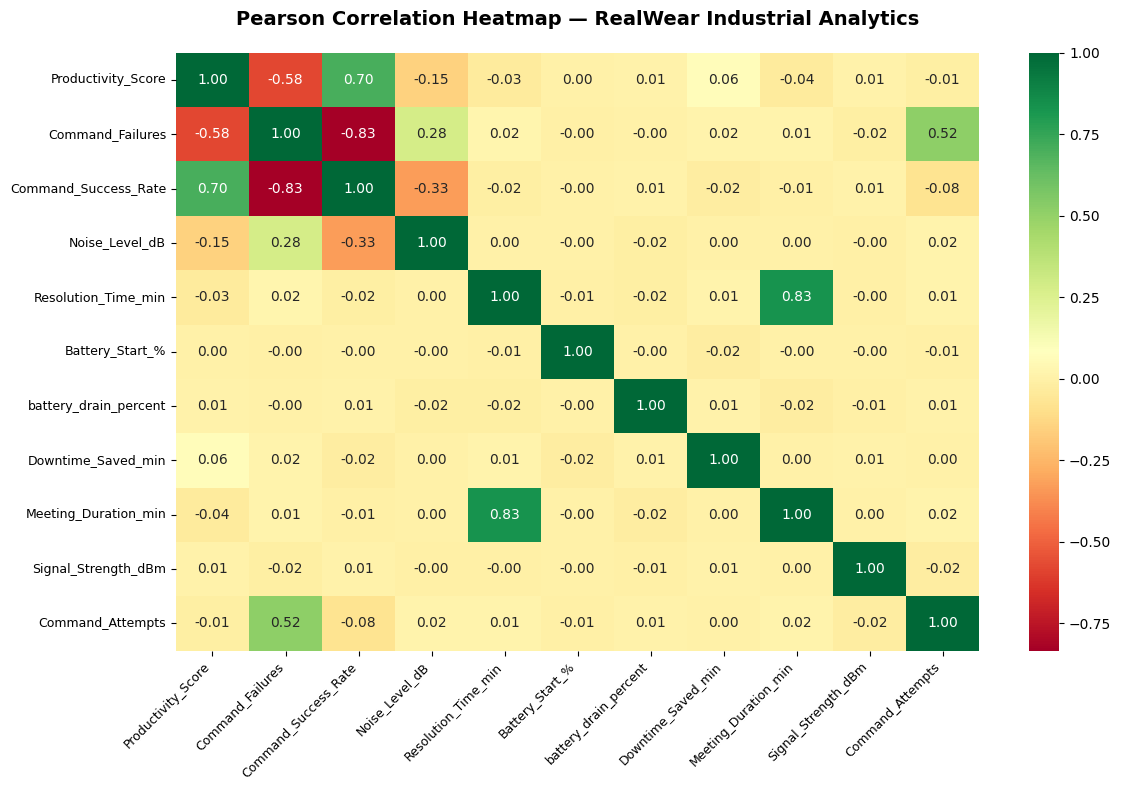

In [16]:
# CORRELATION HEATMAP
plt.figure(figsize=(12, 8))

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation values
    fmt='.2f',            # 2 decimal places
    cmap='RdYlGn',        # Red=negative, Yellow=neutral, Green=positive
)
plt.title('Pearson Correlation Heatmap — RealWear Industrial Analytics',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

In [17]:
# TOP FACTORS INFLUENCING PRODUCTIVITY
#Get correlations with Productivity_Score only
productivity_corr = corr_matrix['Productivity_Score'].drop('Productivity_Score')
productivity_corr = productivity_corr.sort_values(key=abs, ascending=False)
print("\nRank | Factor                  | Correlation | Strength    | Direction")
for rank, (factor, corr) in enumerate(productivity_corr.items(), 1):
    # Strength
    if abs(corr) >= 0.7:
        strength = 'Strong'
    elif abs(corr) >= 0.4:
        strength = 'Moderate'
    elif abs(corr) >= 0.2:
        strength = 'Weak'
    else:
        strength = 'Negligible'
    
    # Direction
    direction = 'Positive ↑' if corr > 0 else 'Negative ↓'
    
    print(f"  {rank:2}  | {factor:25} | {corr:+.4f}     | {strength:10} | {direction}")

print("=" * 60)
print("\nInterpretation Guide:")
print("  |r| >= 0.7 → Strong correlation")
print("  |r| >= 0.4 → Moderate correlation")
print("  |r| >= 0.2 → Weak correlation")
print("  |r| <  0.2 → Negligible correlation")



Rank | Factor                  | Correlation | Strength    | Direction
   1  | Command_Success_Rate      | +0.6996     | Moderate   | Positive ↑
   2  | Command_Failures          | -0.5805     | Moderate   | Negative ↓
   3  | Noise_Level_dB            | -0.1521     | Negligible | Negative ↓
   4  | Downtime_Saved_min        | +0.0625     | Negligible | Positive ↑
   5  | Meeting_Duration_min      | -0.0352     | Negligible | Negative ↓
   6  | Resolution_Time_min       | -0.0327     | Negligible | Negative ↓
   7  | Command_Attempts          | -0.0123     | Negligible | Negative ↓
   8  | Signal_Strength_dBm       | +0.0081     | Negligible | Positive ↑
   9  | battery_drain_percent     | +0.0058     | Negligible | Positive ↑
  10  | Battery_Start_%           | +0.0025     | Negligible | Positive ↑

Interpretation Guide:
  |r| >= 0.7 → Strong correlation
  |r| >= 0.4 → Moderate correlation
  |r| >= 0.2 → Weak correlation
  |r| <  0.2 → Negligible correlation


Is the choice of platform (MS Teams vs Webex) independent of which plant the worker is in? Or does plant location influence which platform gets used?

CHI-SQUARE TEST OF INDEPENDENCE

Ho:Platform choice is independent of plant location

Ha:PLatform choice is dependent on plant location

Significance Level:alpha=0.05


A contingency table (also known as a crosstab or two-way table) is a matrix format used in statistics to summarize the relationship between two or more categorical variables. It displays the frequency distribution of the variables simultaneously, allowing you to see how often certain combinations of categories occur



In [20]:
from scipy.stats import chi2_contingency

contingency_table=pd.crosstab(df['Plant_Location'],df['Platform'])
print("\nCONTINGENCY TABLE (Observed Frequencies):")
print(contingency_table)

#chi-square test
chi2,p_value,dof,expected=chi2_contingency(contingency_table)

print(f"CHI-SQUARE RESULTS:")
print(f"Chi-Square Staistics:{chi2:.4f}")
print(f"P-Value:{p_value:.6f}")
print(f"Degree of freedom:{dof}")

if p_value<0.05:
    print("DECISION:Reject Ho")
    print("Conclusion:Platform choice is Dependent on plant Location")
else:
    print("\nDECISION: Fail to Reject H0")
    print("CONCLUSION: Platform choice is INDEPENDENT of plant location")

# Effect Size — Cramer's V
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"\nEFFECT SIZE (Cramer's V): {cramers_v:.4f}")

if cramers_v<0.1:
    print("Interpretation:Negligible association")

elif cramers_v<0.3:
    print("Interpretaion:Small association")

elif cramers_v<0.5:
    print("Interpretaion:Moderate association")

else:
    print("Interpreation:Strong association")












CONTINGENCY TABLE (Observed Frequencies):
Platform                  MS Teams  Webex
Plant_Location                           
Bokaro Manufacturing Hub      1691    742
Chennai Refinery Unit         1645    787
Jamshedpur Steel Plant        1638    765
Pune Automation Plant         1658    763
Vadodara Chemical Unit        1557    754
CHI-SQUARE RESULTS:
Chi-Square Staistics:3.0677
P-Value:0.546567
Degree of freedom:4

DECISION: Fail to Reject H0
CONCLUSION: Platform choice is INDEPENDENT of plant location

EFFECT SIZE (Cramer's V): 0.0160
Interpretation:Negligible association


Outlier Detection

IQR METHOD+Z-SCORE METHOD



Column                          Q1       Q3      IQR    Lower    Upper    Count      Pct
Productivity_Score            59.7     89.5     29.8     15.0    134.2        0      0.0%
Command_Failures               2.0      8.0      6.0     -7.0     17.0      275     2.29%
Resolution_Time_min           25.8     68.3     42.5   -37.95   132.05       15     0.12%
Noise_Level_dB                63.3     99.4     36.1     9.15   153.55        0      0.0%
battery_drain_percent          7.7     17.2      9.5    -6.55    31.45        0      0.0%
Downtime_Saved_min            27.1     72.0     44.9   -40.25   139.35        0      0.0%


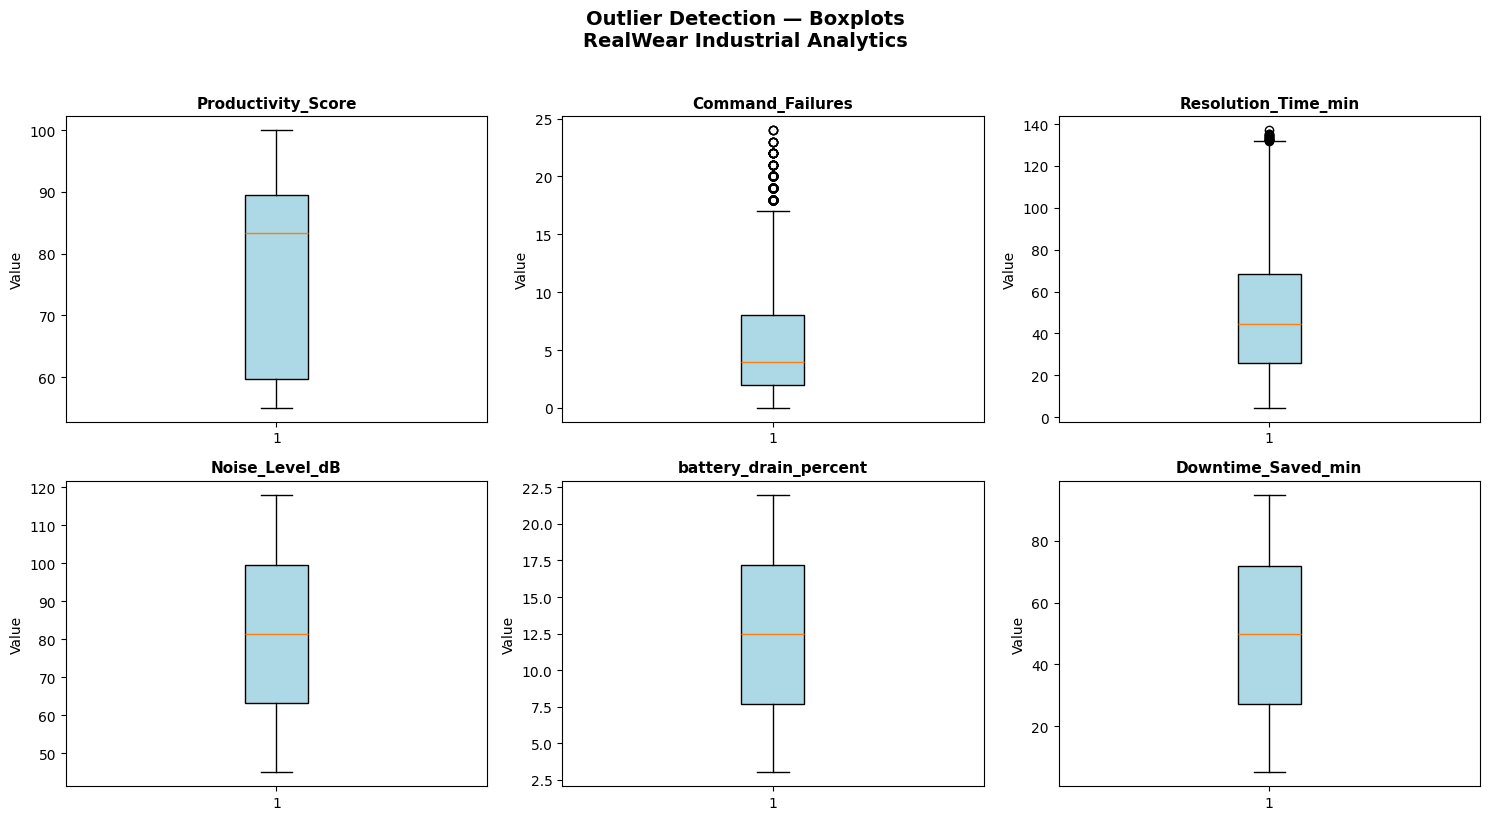

In [45]:
#Column to check outliers
outlier_cols=['Productivity_Score','Command_Failures',
              'Resolution_Time_min','Noise_Level_dB',
              'battery_drain_percent','Downtime_Saved_min']

iqr_summary=[]

for col in outlier_cols:

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    iqr_outliers=df[(df[col]<lower_bound)| (df[col]>upper_bound)]
    iqr_count=len(iqr_outliers)
    iqr_pct=round(iqr_count/len(df)*100,2)

    iqr_summary.append({
        'Column':col,
        'Q1':round(Q1,2),
        'Q3':round(Q3,2),
        'IQR':round(IQR,2),
        'Lower_Bound':round(lower_bound,2),
        'Upper_bound':round(upper_bound,2),
        'Outlier_count':iqr_count,
        'Outlier_Pct':iqr_pct


    })
iqr_df=pd.DataFrame(iqr_summary)
print(f"\n{'Column':<25} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8} {'Count':>8} {'Pct':>8}")
for _,row in iqr_df.iterrows():
    print(f"{row['Column']:<25} {row['Q1']:>8} {row['Q3']:>8} {row['IQR']:>8} {row['Lower_Bound']:>8} {row['Upper_bound']:>8} {row['Outlier_count']:>8} {row['Outlier_Pct']:>8}%")


fig,axes=plt.subplots(2,3,figsize=(15,8))
axes=axes.flatten()
for idx,col in enumerate(outlier_cols):
    axes[idx].boxplot(df[col].dropna(),patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))
    axes[idx].set_title(col,fontsize=11,fontweight='bold')
    axes[idx].set_ylabel('Value')
plt.suptitle('Outlier Detection — Boxplots\nRealWear Industrial Analytics',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()

   

In [37]:
# ============================================
# Z-SCORE MANUAL IMPLEMENTATION
# Z-Score = (Value - Mean) / Standard Deviation
# ============================================

print("=" * 60)
print("MANUAL Z-SCORE IMPLEMENTATION")
print("=" * 60)
print("Formula: Z = (X - mean) / std")
print("Outlier threshold: |Z| > 3")
print("=" * 60)

for col in outlier_cols:
    
    col_mean = df[col].mean()
    col_std = df[col].std()
    
    # Manual Z-Score calculation
    df[f'zscore_{col}'] = (df[col] - col_mean) / col_std
    
    # Flag outliers where |Z| > 3
    outliers = df[df[f'zscore_{col}'].abs() > 3]
    outlier_count = len(outliers)
    outlier_pct = round(outlier_count / len(df) * 100, 2)
    
    print(f"\n{col}:")
    print(f"  Mean            : {col_mean:.2f}")
    print(f"  Std             : {col_std:.2f}")
    print(f"  Outliers (|Z|>3): {outlier_count} sessions ({outlier_pct}%)")
    print(f"  Min Z-Score     : {df[f'zscore_{col}'].min():.2f}")
    print(f"  Max Z-Score     : {df[f'zscore_{col}'].max():.2f}")

MANUAL Z-SCORE IMPLEMENTATION
Formula: Z = (X - mean) / std
Outlier threshold: |Z| > 3

Productivity_Score:
  Mean            : 77.50
  Std             : 14.80
  Outliers (|Z|>3): 0 sessions (0.0%)
  Min Z-Score     : -1.52
  Max Z-Score     : 1.52

Command_Failures:
  Mean            : 5.60
  Std             : 4.58
  Outliers (|Z|>3): 94 sessions (0.78%)
  Min Z-Score     : -1.22
  Max Z-Score     : 4.02

Resolution_Time_min:
  Mean            : 49.26
  Std             : 29.05
  Outliers (|Z|>3): 1 sessions (0.01%)
  Min Z-Score     : -1.54
  Max Z-Score     : 3.02

Noise_Level_dB:
  Mean            : 81.39
  Std             : 20.99
  Outliers (|Z|>3): 0 sessions (0.0%)
  Min Z-Score     : -1.73
  Max Z-Score     : 1.74

battery_drain_percent:
  Mean            : 12.47
  Std             : 5.51
  Outliers (|Z|>3): 0 sessions (0.0%)
  Min Z-Score     : -1.72
  Max Z-Score     : 1.73

Downtime_Saved_min:
  Mean            : 49.75
  Std             : 26.08
  Outliers (|Z|>3): 0 sessions (